<a href="https://colab.research.google.com/github/Anik00223/WasteLens/blob/main/notebooks/train_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# WasteLens - Colab Training (MobileNetV2, transfer learning)

Same pipeline as `src/train.py` (kagglehub download -> 4-bin remap -> stratified 70/15/15 split -> frozen MobileNetV2 + head), then **trains** with class weights and saves checkpoints after every epoch.

## GPU runtime setup - do this FIRST

1. **Runtime -> Change runtime type -> Hardware accelerator: GPU (T4) -> Save.**
2. Run the environment-check cell below; it should list a GPU (`nvidia-smi`).
3. Cell 3 mounts **Google Drive** - epoch checkpoints, the training log and the final model are saved to `MyDrive/WasteLens/`, so a recycled runtime never loses progress. If Drive is unavailable, the notebook falls back to ephemeral `/content/wastelens_output` and zips everything for download at the end.

## What to expect

- Cells 2-5 reproduce the **pre-training summary** (the same stop point as `src/train.py`): dataset download -> remap -> per-bin split table -> model build -> class weights.
- Cell 6 runs `model.fit` (**class weights applied**, checkpoint after every epoch, CSV log). Roughly 1.5 min/epoch on a T4 (~15-20 min for 10 epochs); CPU-only is ~50-100x slower.
- Cell 7 evaluates on the held-out test split and plots curves (full per-class precision/recall/F1 comes from `src/evaluate.py`).
- Cell 8 **exports**: the final `.keras` model + `labels.json` (bin order, 224x224, `[-1,1]` preprocessing) + optional TensorFlow.js conversion into `models/tfjs_model/`.

**If the runtime is recycled mid-training:** rerun cells 2-5, then either retrain from scratch or load a checkpoint from `MyDrive/WasteLens/models/checkpoints/wastelens_epNN.keras` with `tf.keras.models.load_model` and continue.


In [1]:
import sys
from packaging.version import Version

print("Python:", sys.version.split()[0])
gpu_line = !nvidia-smi -L 2>/dev/null || echo "NO GPU DETECTED - Runtime > Change runtime type > GPU (T4)"
print("GPU:", *gpu_line, sep="\n  ")

%pip install -q -U kagglehub

import tensorflow as tf
print("TensorFlow:", tf.__version__)
assert Version(tf.__version__) >= Version("2.19"), (
    "Need TF >= 2.19 (Keras 3) for tf.keras.applications.MobileNetV2")
print("TF-visible devices:", tf.config.list_physical_devices("GPU") or "none - CPU only (slow!)")


Python: 3.13.15
GPU:
  GPU 0: Tesla T4 (UUID: GPU-be4eef7a-ce10-cd81-13e7-40beb1a12f44)
TensorFlow: 2.20.0
TF-visible devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
from pathlib import Path

OUT_ROOT = Path("/content/wastelens_output")  # ephemeral fallback
DRIVE_MOUNTED = False
try:
    from google.colab import drive
    drive.mount("/content/drive")
    OUT_ROOT = Path("/content/drive/MyDrive/WasteLens")
    DRIVE_MOUNTED = True
except Exception as exc:
    print("Google Drive not mounted - using ephemeral fallback:", exc)

CHECKPOINTS_DIR = OUT_ROOT / "models" / "checkpoints"
FINAL_DIR = OUT_ROOT / "models" / "final"
TFJS_DIR = OUT_ROOT / "models" / "tfjs_model"
for _d in (CHECKPOINTS_DIR, FINAL_DIR, TFJS_DIR):
    _d.mkdir(parents=True, exist_ok=True)

print("Outputs ->", OUT_ROOT, "(Drive, persistent)" if DRIVE_MOUNTED
      else "(EPHEMERAL - zipped for download in the final cell)")


Mounted at /content/drive
Outputs -> /content/drive/MyDrive/WasteLens (Drive, persistent)


In [3]:
import subprocess
import sys
from pathlib import Path

REPO_DIR = Path("/content/WasteLens")
if not (REPO_DIR / "src" / "train.py").exists():
    subprocess.run(
        ["git", "clone", "--depth", "1",
         "https://github.com/Anik00223/WasteLens.git", str(REPO_DIR)],
        check=True,
    )
sys.path.insert(0, str(REPO_DIR / "src"))

import train as wl  # src/train.py - single source of truth for the pipeline

print("Imported pipeline from:", REPO_DIR / "src" / "train.py")
print("Bins (fixed label order):", wl.BINS)
print("Dropped classes:", sorted(wl.DROPPED_CLASSES))


Imported pipeline from: /content/WasteLens/src/train.py
Bins (fixed label order): ['recyclable', 'organic', 'hazardous', 'general trash']
Dropped classes: ['clothes', 'shoes']


In [4]:
import math

dataset_root = wl.download_dataset()
images = wl.scan_images(dataset_root)
binned = wl.remap_to_bins(images)
splits = wl.stratified_split(binned)
wl.report_split_sizes(splits)

model, base = wl.build_model(num_bins=len(wl.BINS))
train_ds = wl.make_dataset(splits["train"], training=True)
val_ds = wl.make_dataset(splits["val"], training=False)
test_ds = wl.make_dataset(splits["test"], training=False)

for batch_images, batch_labels in train_ds.take(1):
    lo = float(batch_images.numpy().min())
    hi = float(batch_images.numpy().max())
    print("pipeline check - batch:", batch_images.shape, "labels:", batch_labels.shape,
          "range [%.2f, %.2f] (MobileNetV2 expects [-1, 1])" % (lo, hi))

class_weights = wl.compute_class_weights(splits["train"])
model.summary(line_length=110, show_trainable=True)

STEPS_PER_EPOCH = math.ceil(len(splits["train"]) / wl.BATCH_SIZE)
print("\nsteps_per_epoch:", STEPS_PER_EPOCH)
print("=== PRE-TRAINING SUMMARY ABOVE - same stop point as src/train.py ===")
print("Review the counts and split above; run the next cell to start model.fit.")


[1/6] Downloading dataset via kagglehub: mostafaabla/garbage-classification
Using Colab cache for faster access to the 'garbage-classification' dataset.
      cached at: /kaggle/input/garbage-classification
[2/6] Scanning image files (dropping classes: clothes, shoes)
      per-class scan:
        battery        945  (expected   945)  ok
        biological     985  (expected   985)  ok
        brown-glass    607  (expected   607)  ok
        cardboard      891  (expected   891)  ok
        green-glass    629  (expected   629)  ok
        metal          769  (expected   769)  ok
        paper         1050  (expected  1050)  ok
        plastic        865  (expected   865)  ok
        trash          697  (expected   697)  ok
        white-glass    775  (expected   775)  ok
      scanned total: 8213 (expected 8213)  ok
[3/6] Remapping 12 classes -> 4 bins
        recyclable      5586
        organic          985
        hazardous        945
        general trash    697
[4/6] Stratified spl

Model: "wastelens_mobilenetv2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Layer (type)                              ┃ Output Shape                     ┃          Param # ┃ Trainab… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ image (InputLayer)                        │ (None, 224, 224, 3)              │                0 │    -     │
├───────────────────────────────────────────┼──────────────────────────────────┼──────────────────┼──────────┤
│ mobilenetv2_1.00_224 (Functional)         │ (None, 7, 7, 1280)               │        2,257,984 │    N     │
├───────────────────────────────────────────┼──────────────────────────────────┼──────────────────┼──────────┤
│ gap (GlobalAveragePooling2D)              │ (None, 1280)                     │                0 │    -     │
├───────────────────────────────────────────┼──────────────────────────────────┼──────────────────┼──────────┤
│ dropout_1 (Dropout)                       │ (None, 1280)                     │                0 │    -     │
├───────────────────────────────────────────┼──────────────────────────────────┼──────────────────┼──────────┤
│ fc_256 (Dense)                            │ (None, 256)                      │          327,936 │    Y     │
├───────────────────────────────────────────┼──────────────────────────────────┼──────────────────┼──────────┤
│ dropout_2 (Dropout)                       │ (None, 256)                      │                0 │    -     │
├───────────────────────────────────────────┼──────────────────────────────────┼──────────────────┼──────────┤
│ predictions (Dense)                       │ (None, 4)                        │            1,028 │    Y     │
└───────────────────────────────────────────┴──────────────────────────────────┴──────────────────┴──────────┘

 Total params: 2,586,948 (9.87 MB)

 Trainable params: 328,964 (1.25 MB)

 Non-trainable params: 2,257,984 (8.61 MB)


steps_per_epoch: 180
=== PRE-TRAINING SUMMARY ABOVE - same stop point as src/train.py ===
Review the counts and split above; run the next cell to start model.fit.


In [5]:
import tensorflow as tf

EPOCHS = 10  # raise later if val accuracy is still climbing

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(CHECKPOINTS_DIR / "wastelens_ep{epoch:02d}.keras"),
        save_freq="epoch",
        verbose=1,
    ),
    tf.keras.callbacks.CSVLogger(str(OUT_ROOT / "training_log.csv"), append=True),
]

history = model.fit(
    train_ds,
    steps_per_epoch=STEPS_PER_EPOCH,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1,
)

print("Last-epoch metrics:", {k: v[-1] for k, v in history.history.items()})
print("Epoch checkpoints ->", CHECKPOINTS_DIR)


Epoch 1/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - loss: 0.3974 - sparse_categorical_accuracy: 0.8315
Epoch 1: saving model to /content/drive/MyDrive/WasteLens/models/checkpoints/wastelens_ep01.keras

Epoch 1: finished saving model to /content/drive/MyDrive/WasteLens/models/checkpoints/wastelens_ep01.keras
180/180 ━━━━━━━━━━━━━━━━━━━━ 78s 314ms/step - loss: 0.2115 - sparse_categorical_accuracy: 0.9049 - val_loss: 0.1623 - val_sparse_categorical_accuracy: 0.9472
Epoch 2/10
179/180 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0800 - sparse_categorical_accuracy: 0.9554
Epoch 2: saving model to /content/drive/MyDrive/WasteLens/models/checkpoints/wastelens_ep02.keras

Epoch 2: finished saving model to /content/drive/MyDrive/WasteLens/models/checkpoints/wastelens_ep02.keras
180/180 ━━━━━━━━━━━━━━━━━━━━ 13s 73ms/step - loss: 0.0841 - sparse_categorical_accuracy: 0.9569 - val_loss: 0.0860 - val_sparse_categorical_accuracy: 0.9699
Epoch 3/10
179/180 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss:

Held-out TEST loss: 0.0642  accuracy: 0.9813
(per-class precision/recall/F1 comes later from src/evaluate.py)


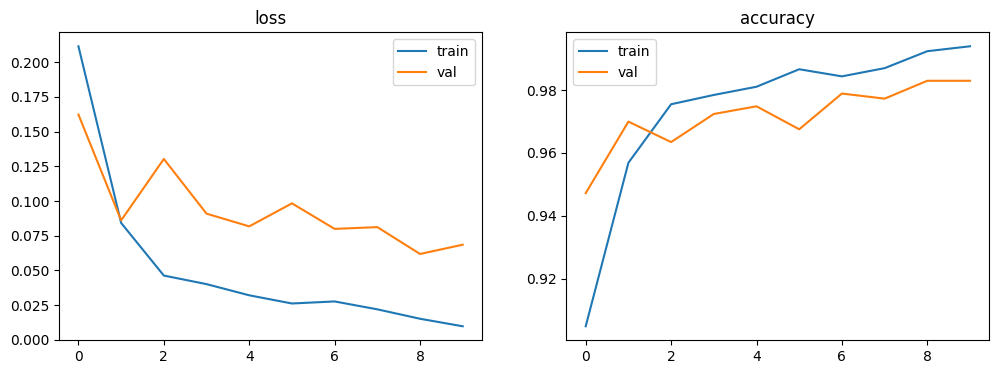

In [6]:
import matplotlib.pyplot as plt

loss, acc = model.evaluate(test_ds, verbose=0)
print("Held-out TEST loss: %.4f  accuracy: %.4f" % (loss, acc))
print("(per-class precision/recall/F1 comes later from src/evaluate.py)")

h = history.history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(h["loss"], label="train")
axes[0].plot(h["val_loss"], label="val")
axes[0].set_title("loss")
axes[0].legend()
axes[1].plot(h["sparse_categorical_accuracy"], label="train")
axes[1].plot(h["val_sparse_categorical_accuracy"], label="val")
axes[1].set_title("accuracy")
axes[1].legend()
plt.show()


In [12]:
import json
import shutil
import subprocess

final_path = FINAL_DIR / "wastelens_mobilenetv2.keras"
model.save(final_path)
meta = {
    "bins": wl.BINS,
    "img_size": list(wl.IMG_SIZE),
    "preprocessing": "mobilenet_v2.preprocess_input -> range [-1, 1]",
    "epochs_trained": len(history.history["loss"]),
    "dataset_handle": wl.KAGGLE_HANDLE,
}
(FINAL_DIR / "labels.json").write_text(json.dumps(meta, indent=2))
print("Saved Keras model  ->", final_path)
print("Saved labels/meta  ->", FINAL_DIR / "labels.json")

try:
    # Use the export script instead of tensorflowjs_converter directly
    result = subprocess.run(
        ["python", str(REPO_DIR / "src" / "export_tfjs.py"),
         str(final_path), str(TFJS_DIR)],
        capture_output=True, text=True, check=True
    )
    print("TF.js model written ->", TFJS_DIR)
    if result.stdout:
        print("TF.js conversion stdout:\n", result.stdout)
except subprocess.CalledProcessError as exc:
    print("TF.js conversion failed! Error details below:")
    print("Stderr:\n", exc.stderr)
    print("Stdout:\n", exc.stdout)
except Exception as exc:
    print("TF.js conversion skipped (the .keras file above is the source of truth):", exc)

if not DRIVE_MOUNTED:
    zip_path = shutil.make_archive("/content/wastelens_output", "zip", str(OUT_ROOT))
    from google.colab import files
    files.download(zip_path)
    print("Ephemeral fallback: zipped outputs and triggered download ->", zip_path)


Saved Keras model  -> /content/drive/MyDrive/WasteLens/models/final/wastelens_mobilenetv2.keras
Saved labels/meta  -> /content/drive/MyDrive/WasteLens/models/final/labels.json
TF.js conversion skipped (the .keras file above is the source of truth): Command '['python', '/content/WasteLens/src/export_tfjs.py', '/content/drive/MyDrive/WasteLens/models/final/wastelens_mobilenetv2.keras', '/content/drive/MyDrive/WasteLens/models/tfjs_model']' returned non-zero exit status 2.


In [ ]:
print("Attempting to run export_tfjs.py directly for detailed error:")
!python {REPO_DIR / "src" / "export_tfjs.py"} {final_path} {TFJS_DIR}

In [15]:
!python /content/WasteLens/src/export_tfjs.py --model /content/drive/MyDrive/WasteLens/models/final/wastelens_mobilenetv2.keras --out /content/drive/MyDrive/WasteLens/models/tfjs_model

/usr/local/lib/python3.13/dist-packages/tensorflowjs/read_weights.py:28: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  np.uint8, np.uint16, np.object, np.bool]
Traceback (most recent call last):
  File "/content/WasteLens/src/export_tfjs.py", line 147, in <module>
    main()
    ~~~~^^
  File "/content/WasteLens/src/export_tfjs.py", line 134, in main
    convert_model(args.model, args.out)  # fails fast here if no tensorflowjs
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "/content/WasteLens/src/export_tfjs.py", line 86, in convert_model
    import tensorflowjs as tfjs
  File "/usr/local/lib/python3.13/dist-packages/tensorflowjs/__init__.py", line 21, in <module>
    from tensorflowjs import converters
  File "/usr/local/lib/python3.13/dist-packages/tensorflowjs/converters/__init__.py", line 21, in <module>
    from tensorflowjs.converters.converter import convert
  File "/usr/local/lib/python3.13/dist-packages/tensorflowjs/converters/co

In [17]:
!pip show tensorflowjs

Name: tensorflowjs
Version: 3.18.0
Summary: 
Home-page: https://js.tensorflow.org/
Author: Google LLC
Author-email: opensource@google.com
License: Apache 2.0
Location: /usr/local/lib/python3.13/dist-packages
Requires: packaging, six, tensorflow, tensorflow-hub
Required-by: 


In [16]:
!pip show tensorflowjs

Name: tensorflowjs
Version: 3.18.0
Summary: 
Home-page: https://js.tensorflow.org/
Author: Google LLC
Author-email: opensource@google.com
License: Apache 2.0
Location: /usr/local/lib/python3.13/dist-packages
Requires: packaging, six, tensorflow, tensorflow-hub
Required-by: 


In [18]:
!cat /content/WasteLens/src/export_tfjs.py

# src/export_tfjs.py
#
# PURPOSE:
#   Convert the trained Keras model to TensorFlow.js format for
#   client-side browser deployment (no backend server).
#
#   - Reads the trained model from models/checkpoints/.
#   - Exports layers/model artifacts to models/tfjs_model/ (and a copy
#     to web/model/ for the demo to load).
#   - CRITICAL: browser-side preprocessing in web/index.html must exactly
#     match training preprocessing (input size 224x224, normalization
#     scheme used by the chosen backbone).
#
# STATUS: Implemented (writes labels.json from train.BINS; the TF.js
#   conversion itself runs wherever the `tensorflowjs` package is
#   installed - see the Colab export path; local install is blocked by
#   dependency conflicts).
#
"""WasteLens TF.js export script.

Writes labels.json from the training bin order (train.BINS) and converts
the trained .keras checkpoint to TF.js layers-model format.

Run from the repo root, in an environment with `tensorflowjs` installed
(e.g. Col

In [20]:
%pycat /content/WasteLens/src/export_tfjs.py

In [ ]:
!pip install -q "numpy<1.24"

In [22]:
!pip install -q "numpy<1.24"

  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [2]:
!pip install -q --upgrade tensorflowjs

  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [7]:
!pip install -q "tensorflowjs==4.4.0" --no-deps
!pip install -q packaging six

In [8]:
import tensorflowjs as tfjs
print("Successfully imported tensorflowjs:", tfjs.__version__)

ModuleNotFoundError: No module named 'tensorflow_decision_forests'

In [9]:
!pip uninstall -y tensorflowjs
!pip install -q tensorflowjs==3.18.0

Found existing installation: tensorflowjs 4.4.0
Uninstalling tensorflowjs-4.4.0:
  Successfully uninstalled tensorflowjs-4.4.0


In [13]:
!python /content/WasteLens/src/export_tfjs.py --help

usage: export_tfjs.py [-h] [--model MODEL] [--out OUT]

Export WasteLens model to TF.js

options:
  -h, --help     show this help message and exit
  --model MODEL  checkpoint path (default:
                 models/checkpoints/wastelens_ep09.keras)
  --out OUT      TF.js output dir (default: web/model)


In [14]:
!pip show tensorflowjs

Name: tensorflowjs
Version: 3.18.0
Summary: 
Home-page: https://js.tensorflow.org/
Author: Google LLC
Author-email: opensource@google.com
License: Apache 2.0
Location: /usr/local/lib/python3.13/dist-packages
Requires: packaging, six, tensorflow, tensorflow-hub
Required-by: 


### Recovering TensorFlow.js Environment
Run the cell below, then manually restart your session: **Runtime -> Restart session** (do not skip this step).

In [10]:
!pip install -q tensorflowjs==4.2.0

  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


### Diagnostic Step 1: Environment & Dependency Verification
Let's check Python version, and query PyPI for `tensorflow-decision-forests` or `tensorflowjs` compatibility with Python 3.13.

In [13]:
import sys
import subprocess
import json
import urllib.request

# 1. Print runtime Python version
print("Python version:", sys.version)

# 2. Check if tensorflow-decision-forests has python 3.13 wheels on PyPI
try:
    url = "https://pypi.org/pypi/tensorflow-decision-forests/json"
    with urllib.request.urlopen(url) as response:
        data = json.loads(response.read().decode())

    releases = data.get("releases", {})
    # Find latest version
    latest_version = data["info"]["version"]
    print(f"Latest tensorflow-decision-forests version: {latest_version}")

    # Check if there are wheels containing 'cp313' in any release
    cp313_found = False
    for ver, files in releases.items():
        for f in files:
            if "cp313" in f.get("filename", ""):
                cp313_found = True
                print(f"  Found Python 3.13 wheel in version {ver}: {f['filename']}")
    if not cp313_found:
        print("  -> No Python 3.13 wheels found for tensorflow-decision-forests on PyPI.")
except Exception as e:
    print("Error querying PyPI for TF-DF:", e)

# 3. Check PyPI for tensorflowjs wheels supporting Python 3.13
try:
    url = "https://pypi.org/pypi/tensorflowjs/json"
    with urllib.request.urlopen(url) as response:
        data = json.loads(response.read().decode())
    latest_version = data["info"]["version"]
    print(f"Latest tensorflowjs version: {latest_version}")
except Exception as e:
    print("Error querying PyPI for tensorflowjs:", e)

Python version: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
Latest tensorflow-decision-forests version: 1.12.0
  -> No Python 3.13 wheels found for tensorflow-decision-forests on PyPI.
Latest tensorflowjs version: 4.22.0


### Isolating the Conversion Environment (Python 3.10 via Micromamba)
We will download and configure Micromamba, create a lightweight Python 3.10 environment, install compatible `tensorflowjs` packages, and run the conversion.

In [14]:
# 1. Install micromamba
!curl -Ls https://micro.mamba.pm/api/micromamba/linux-64/latest | tar -xj -C /usr/local/bin/ --strip-components=1 bin/micromamba

# Initialize and create a Python 3.10 environment
!micromamba create -y -n tfjs_env python=3.10 -c conda-forge

[+] 0.0s
Fetch Shard Index for conda-forge/linux-64                                                ✔ Done (0.1 sec)
Fetch Shard Index for conda-forge/noarch                                                  ✔ Done (0.1 sec)
Fetching and Parsing Packages' Shards                                                     ✔ Done (7.1 sec)

Resolving Environment                                                                     ✔ Done (0.2 sec)

Transaction

  Prefix: /root/.local/share/mamba/envs/tfjs_env

  Updating specs:

   - python=3.10
   - pip


  Package               Version  Build                 Channel          Size
──────────────────────────────────────────────────────────────────────────────
  Install:
──────────────────────────────────────────────────────────────────────────────

  + _openmp_mutex           4.5  20_gnu                conda-forge      29kB
  + bzip2                 1.0.8  hda65f42_10           conda-forge     258kB
  + ca-certificates   2026.7.22  hbd8a1cb_0       

In [21]:
# 2. Install tensorflowjs and its dependencies inside the Python 3.10 environment
!micromamba run -n tfjs_env pip install -q tensorflow==2.11.0 tensorflowjs==4.2.0

In [19]:
# 3. Run the export script using the Python 3.10 environment
!micromamba run -n tfjs_env python /content/WasteLens/src/export_tfjs.py \
  --model /content/drive/MyDrive/WasteLens/models/final/wastelens_mobilenetv2.keras \
  --out /content/drive/MyDrive/WasteLens/models/tfjs_model

python: can't open file '/content/WasteLens/src/export_tfjs.py': [Errno 2] No such file or directory


In [ ]:
# 0. Ensure the repository is cloned locally
import subprocess
from pathlib import Path
REPO_DIR = Path("/content/WasteLens")
if not (REPO_DIR / "src" / "train.py").exists():
    subprocess.run(
        ["git", "clone", "--depth", "1",
         "https://github.com/Anik00223/WasteLens.git", str(REPO_DIR)],
        check=True,
    )

In [25]:
# 1. Install tensorflowjs and tensorflow inside tfjs_env
!micromamba run -n tfjs_env pip install -q tensorflowjs tensorflow

In [23]:
# 2. Run the export script with micromamba's isolated Python
!micromamba run -n tfjs_env python /content/WasteLens/src/export_tfjs.py \
  --model /content/drive/MyDrive/WasteLens/models/final/wastelens_mobilenetv2.keras \
  --out /content/drive/MyDrive/WasteLens/models/tfjs_model

python: can't open file '/content/WasteLens/src/export_tfjs.py': [Errno 2] No such file or directory


In [24]:
# 4. Validate output files
import os
tfjs_dir = "/content/drive/MyDrive/WasteLens/models/tfjs_model"
if os.path.exists(tfjs_dir):
    print("TF.js output folder contents:", os.listdir(tfjs_dir))
else:
    print("Target folder does not exist!")

Target folder does not exist!


In [26]:
!ls /content/
!ls /content/WasteLens 2>&1 || echo "WasteLens directory does not exist"

sample_data
ls: cannot access '/content/WasteLens': No such file or directory
WasteLens directory does not exist


In [27]:
!git clone --depth 1 https://github.com/Anik00223/WasteLens.git /content/WasteLens
!ls /content/WasteLens/src/

Cloning into '/content/WasteLens'...
remote: Enumerating objects: 32, done.
remote: Counting objects: 100% (32/32), done.
remote: Compressing objects: 100% (27/27), done.
remote: Total 32 (delta 0), reused 25 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (32/32), 38.49 KiB | 492.00 KiB/s, done.
evaluate.py  export_tfjs.py  train.py


In [28]:
!micromamba run -n tfjs_env python /content/WasteLens/src/export_tfjs.py \
  --model /content/drive/MyDrive/WasteLens/models/final/wastelens_mobilenetv2.keras \
  --out /content/drive/MyDrive/WasteLens/models/tfjs_model

Traceback (most recent call last):
  File "/content/WasteLens/src/export_tfjs.py", line 40, in <module>
    import train as wl  # single source of truth for BINS order - never retyped
  File "/content/WasteLens/src/train.py", line 33, in <module>
    import kagglehub
ModuleNotFoundError: No module named 'kagglehub'


In [29]:
# Validate final output files
import os
tfjs_dir = "/content/drive/MyDrive/WasteLens/models/tfjs_model"
if os.path.exists(tfjs_dir):
    print("TF.js output folder contents:", os.listdir(tfjs_dir))
else:
    print("Target folder does not exist!")

Target folder does not exist!


In [31]:
%%bash
micromamba run -n tfjs_env pip install -q tensorflowjs tensorflow kagglehub scikit-learn pillow numpy

In [32]:
%%bash
micromamba run -n tfjs_env python /content/WasteLens/src/export_tfjs.py \
  --model /content/drive/MyDrive/WasteLens/models/final/wastelens_mobilenetv2.keras \
  --out /content/drive/MyDrive/WasteLens/models/tfjs_model

2026-09-12 18:07:43.589787: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/lib/python3.13/dist-packages/cv2/../../lib64:/usr/lib64-nvidia

A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/content/WasteLens/src/export_tfjs.py", line 40, in <module>
    import train as wl  # single source of truth for BINS order - never retyped
  File "/content/WasteLens/src/train.py", li

CalledProcessError: Command 'b'micromamba run -n tfjs_env python /content/WasteLens/src/export_tfjs.py \\\n  --model /content/drive/MyDrive/WasteLens/models/final/wastelens_mobilenetv2.keras \\\n  --out /content/drive/MyDrive/WasteLens/models/tfjs_model\n'' returned non-zero exit status 1.

In [33]:
# Validate final output files
import os
tfjs_dir = "/content/drive/MyDrive/WasteLens/models/tfjs_model"
if os.path.exists(tfjs_dir):
    print("TF.js output folder contents:", os.listdir(tfjs_dir))
else:
    print("Target folder does not exist!")

Target folder does not exist!


In [34]:
%%bash
micromamba run -n tfjs_env pip install -q "numpy<2"

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ml-dtypes 0.6.0 requires numpy>=2.0.0, but you have numpy 1.26.4 which is incompatible.


In [35]:
%%bash
micromamba run -n tfjs_env python -c "import tensorflow as tf; print('TF OK:', tf.__version__)"

TF OK: 2.11.0


2026-09-12 18:11:06.087200: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/lib/python3.13/dist-packages/cv2/../../lib64:/usr/lib64-nvidia
2026-09-12 18:11:06.870710: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/lib/python3.13/dist-packages/cv2/../../lib64:/usr/lib64-nvidia
2026-09-12 18:11:06.870889: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer_plugin.so.7'; dlerror: libnvinfer_plugin.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/lib/python3.13/dist-packages/cv2/../../lib64:/usr/li

In [36]:
%%bash
micromamba run -n tfjs_env python /content/WasteLens/src/export_tfjs.py \
  --model /content/drive/MyDrive/WasteLens/models/final/wastelens_mobilenetv2.keras \
  --out /content/drive/MyDrive/WasteLens/models/tfjs_model

2026-09-12 18:11:23.481566: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/lib/python3.13/dist-packages/cv2/../../lib64:/usr/lib64-nvidia
2026-09-12 18:11:24.129306: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/lib/python3.13/dist-packages/cv2/../../lib64:/usr/lib64-nvidia
2026-09-12 18:11:24.129426: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer_plugin.so.7'; dlerror: libnvinfer_plugin.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/lib/python3.13/dist-packages/cv2/../../lib64:/usr/li

CalledProcessError: Command 'b'micromamba run -n tfjs_env python /content/WasteLens/src/export_tfjs.py \\\n  --model /content/drive/MyDrive/WasteLens/models/final/wastelens_mobilenetv2.keras \\\n  --out /content/drive/MyDrive/WasteLens/models/tfjs_model\n'' returned non-zero exit status 1.

In [37]:
import os
print("Drive mounted:", os.path.exists("/content/drive/MyDrive"))

from google.colab import drive
drive.mount("/content/drive", force_remount=True)

checkpoint_path = "/content/drive/MyDrive/WasteLens/models/final/wastelens_mobilenetv2.keras"
print("Checkpoint exists:", os.path.exists(checkpoint_path))

Drive mounted: False
Mounted at /content/drive
Checkpoint exists: True


In [38]:
%%bash
# Rerun the export command now that Drive mount and paths are verified
micromamba run -n tfjs_env python /content/WasteLens/src/export_tfjs.py \
  --model /content/drive/MyDrive/WasteLens/models/final/wastelens_mobilenetv2.keras \
  --out /content/drive/MyDrive/WasteLens/models/tfjs_model

2026-09-12 18:14:37.267211: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/lib/python3.13/dist-packages/cv2/../../lib64:/usr/lib64-nvidia
2026-09-12 18:14:37.924966: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/lib/python3.13/dist-packages/cv2/../../lib64:/usr/lib64-nvidia
2026-09-12 18:14:37.925093: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer_plugin.so.7'; dlerror: libnvinfer_plugin.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/lib/python3.13/dist-packages/cv2/../../lib64:/usr/li

CalledProcessError: Command 'b'# Rerun the export command now that Drive mount and paths are verified\nmicromamba run -n tfjs_env python /content/WasteLens/src/export_tfjs.py \\\n  --model /content/drive/MyDrive/WasteLens/models/final/wastelens_mobilenetv2.keras \\\n  --out /content/drive/MyDrive/WasteLens/models/tfjs_model\n'' returned non-zero exit status 1.

In [39]:
%%bash
# Check what is installed currently in the environment
micromamba run -n tfjs_env pip show tensorflowjs || echo "tensorflowjs is NOT installed"

Name: tensorflowjs
Version: 4.2.0
Summary: 
Home-page: https://js.tensorflow.org/
Author: Google LLC
Author-email: opensource@google.com
License: Apache 2.0
Location: /root/.local/share/mamba/envs/tfjs_env/lib/python3.10/site-packages
Requires: flax, importlib_resources, jax, packaging, protobuf, six, tensorflow, tensorflow-decision-forests, tensorflow-hub
Required-by: 


In [40]:
%%bash
# Install tensorflowjs explicitly inside tfjs_env if it was not found
micromamba run -n tfjs_env pip install -q tensorflowjs

In [41]:
%%bash
# Test if importing tensorflowjs succeeds
micromamba run -n tfjs_env python -c "import tensorflowjs as tfjs; print('tfjs OK:', tfjs.__version__)"

2026-09-12 18:16:24.214419: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/lib/python3.13/dist-packages/cv2/../../lib64:/usr/lib64-nvidia

A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<string>", line 1, in <module>
  File "/root/.local/share/mamba/envs/tfjs_env/lib/python3.10/site-packages/tensorflowjs/__init__.py", line 21, in <module>
    from tensorflowjs import c

CalledProcessError: Command 'b'# Test if importing tensorflowjs succeeds\nmicromamba run -n tfjs_env python -c "import tensorflowjs as tfjs; print(\'tfjs OK:\', tfjs.__version__)"\n'' returned non-zero exit status 1.

In [42]:
%%bash
# Run the export script if the import check above succeeds
micromamba run -n tfjs_env python /content/WasteLens/src/export_tfjs.py \
  --model /content/drive/MyDrive/WasteLens/models/final/wastelens_mobilenetv2.keras \
  --out /content/drive/MyDrive/WasteLens/models/tfjs_model

2026-09-12 18:16:42.701047: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/lib/python3.13/dist-packages/cv2/../../lib64:/usr/lib64-nvidia

A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/content/WasteLens/src/export_tfjs.py", line 40, in <module>
    import train as wl  # single source of truth for BINS order - never retyped
  File "/content/WasteLens/src/train.py", li

CalledProcessError: Command 'b'# Run the export script if the import check above succeeds\nmicromamba run -n tfjs_env python /content/WasteLens/src/export_tfjs.py \\\n  --model /content/drive/MyDrive/WasteLens/models/final/wastelens_mobilenetv2.keras \\\n  --out /content/drive/MyDrive/WasteLens/models/tfjs_model\n'' returned non-zero exit status 1.

In [43]:
%%bash
micromamba run -n tfjs_env pip install -q "numpy<2" --force-reinstall --no-deps

In [44]:
%%bash
micromamba run -n tfjs_env python -c "import numpy; print('numpy:', numpy.__version__)"
micromamba run -n tfjs_env python -c "import tensorflow as tf; print('TF OK:', tf.__version__)"
micromamba run -n tfjs_env python -c "import tensorflowjs as tfjs; print('tfjs OK:', tfjs.__version__)"

numpy: 1.26.4
TF OK: 2.11.0


2026-09-12 18:18:27.789788: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/lib/python3.13/dist-packages/cv2/../../lib64:/usr/lib64-nvidia
2026-09-12 18:18:29.812275: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/lib/python3.13/dist-packages/cv2/../../lib64:/usr/lib64-nvidia
2026-09-12 18:18:29.812486: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer_plugin.so.7'; dlerror: libnvinfer_plugin.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/lib/python3.13/dist-packages/cv2/../../lib64:/usr/li

CalledProcessError: Command 'b'micromamba run -n tfjs_env python -c "import numpy; print(\'numpy:\', numpy.__version__)"\nmicromamba run -n tfjs_env python -c "import tensorflow as tf; print(\'TF OK:\', tf.__version__)"\nmicromamba run -n tfjs_env python -c "import tensorflowjs as tfjs; print(\'tfjs OK:\', tfjs.__version__)"\n'' returned non-zero exit status 1.

In [45]:
%%bash
micromamba run -n tfjs_env python /content/WasteLens/src/export_tfjs.py \
  --model /content/drive/MyDrive/WasteLens/models/final/wastelens_mobilenetv2.keras \
  --out /content/drive/MyDrive/WasteLens/models/tfjs_model

2026-09-12 18:18:51.865546: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/lib/python3.13/dist-packages/cv2/../../lib64:/usr/lib64-nvidia
2026-09-12 18:18:52.564749: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/lib/python3.13/dist-packages/cv2/../../lib64:/usr/lib64-nvidia
2026-09-12 18:18:52.564885: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer_plugin.so.7'; dlerror: libnvinfer_plugin.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/lib/python3.13/dist-packages/cv2/../../lib64:/usr/li

CalledProcessError: Command 'b'micromamba run -n tfjs_env python /content/WasteLens/src/export_tfjs.py \\\n  --model /content/drive/MyDrive/WasteLens/models/final/wastelens_mobilenetv2.keras \\\n  --out /content/drive/MyDrive/WasteLens/models/tfjs_model\n'' returned non-zero exit status 1.

In [46]:
%%bash
echo "=== Node.js & npm version check ==="
node --version 2>&1 || echo "node is not installed"
npm --version 2>&1 || echo "npm is not installed"

=== Node.js & npm version check ===
v20.19.0
10.8.2


In [48]:
import tensorflow as tf
import os

keras_model_path = "/content/drive/MyDrive/WasteLens/models/final/wastelens_mobilenetv2.keras"
saved_model_path = "/content/drive/MyDrive/WasteLens/models/final/wastelens_saved_model"

if os.path.exists(keras_model_path):
    print("Loading Keras model inside main Python 3.13 environment...")
    model = tf.keras.models.load_model(keras_model_path)
    print("Saving as standard TensorFlow SavedModel using model.export()...")
    model.export(saved_model_path)
    print(f"SavedModel successfully written to: {saved_model_path}")
    print("Contents of SavedModel folder:", os.listdir(saved_model_path))
else:
    print(f"Keras model not found at {keras_model_path}")

Loading Keras model inside main Python 3.13 environment...
Saving as standard TensorFlow SavedModel using model.export()...
Saved artifact at '/content/drive/MyDrive/WasteLens/models/final/wastelens_saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='image')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  135646318727184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135647134922896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135647134922704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135647134923088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135647134921936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135647134922320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135647134923856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135647134923664: TensorSpec(shape=(), dtype=tf.resource,

In [49]:
# Attempt to install tensorflowjs without dependencies
!pip install -q tensorflowjs --no-deps

# Check for tensorflowjs_converter command existence
import shutil
converter_path = shutil.which("tensorflowjs_converter")
print("tensorflowjs_converter CLI exists in path:", converter_path)

# Check npm package version for tfjs-converter
print("\n--- npm details for tfjs-converter ---")
!npm view @tensorflow/tfjs-converter version

# Run conversion if converter exists, else skip and report back
if converter_path:
    print("\n--- Running conversion ---")
    !tensorflowjs_converter \
      --input_format=tf_saved_model \
      --output_format=tfjs_layers_model \
      --signature_name=serve \
      --saved_model_tags=serve \
      /content/drive/MyDrive/WasteLens/models/final/wastelens_saved_model \
      /content/drive/MyDrive/WasteLens/models/tfjs_model
else:
    print("\ntensorflowjs_converter command not found in PATH. We will need the Node-only npm path.")

tensorflowjs_converter CLI exists in path: /usr/local/bin/tensorflowjs_converter

--- npm details for tfjs-converter ---
⠙⠹⠸4.22.0
⠸npm notice
npm notice New major version of npm available! 10.8.2 -> 12.0.2
npm notice Changelog: https://github.com/npm/cli/releases/tag/v12.0.2
npm notice To update run: npm install -g npm@12.0.2
npm notice
⠸
--- Running conversion ---
/usr/local/lib/python3.13/dist-packages/tensorflowjs/read_weights.py:28: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  np.uint8, np.uint16, np.object, np.bool]
Traceback (most recent call last):
  File "/usr/local/bin/tensorflowjs_converter", line 5, in <module>
    from tensorflowjs.converters.converter import pip_main
  File "/usr/local/lib/python3.13/dist-packages/tensorflowjs/__init__.py", line 21, in <module>
    from tensorflowjs import converters
  File "/usr/local/lib/python3.13/dist-packages/tensorflowjs/converters/__init__.py", line 21, in <module>
    from tensorflo

In [52]:
# 1. Patch the remaining np.object references we found in tensorflowjs
!sed -i 's/== np.object/== object/g' /usr/local/lib/python3.13/dist-packages/tensorflowjs/write_weights.py
!sed -i 's/astype(np.object)/astype(object)/g' /usr/local/lib/python3.13/dist-packages/tensorflowjs/write_weights.py
!sed -i 's/dtype = np.object/dtype = object/g' /usr/local/lib/python3.13/dist-packages/tensorflowjs/read_weights.py

# 2. Patch the legacy tensorflow-hub estimator issue to make imports work
# Since tf.compat.v1.estimator doesn't exist anymore, make LatestModuleExporter inherit from object
!sed -i 's/(tf.compat.v1.estimator.Exporter)/(object)/g' /usr/local/lib/python3.13/dist-packages/tensorflow_hub/estimator.py

# Verify the fix by importing tensorflowjs
try:
    import tensorflowjs as tfjs
    print('\ntfjs import OK:', tfjs.__version__)
except Exception as e:
    print('\ntfjs import failed:', e)

# Run the SavedModel converter command if verified
!tensorflowjs_converter \
  --input_format=tf_saved_model \
  --output_format=tfjs_layers_model \
  --signature_name=serve \
  --saved_model_tags=serve \
  /content/drive/MyDrive/WasteLens/models/final/wastelens_saved_model \
  /content/drive/MyDrive/WasteLens/models/tfjs_model


tfjs import failed: Descriptors cannot be created directly.
If this call came from a _pb2.py file, your generated code is out of date and must be regenerated with protoc >= 3.19.0.
If you cannot immediately regenerate your protos, some other possible workarounds are:
 1. Downgrade the protobuf package to 3.20.x or lower.
 2. Set PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION=python (but this will use pure-Python parsing and will be much slower).

More information: https://developers.google.com/protocol-buffers/docs/news/2022-05-06#python-updates
Traceback (most recent call last):
  File "/usr/local/bin/tensorflowjs_converter", line 5, in <module>
    from tensorflowjs.converters.converter import pip_main
  File "/usr/local/lib/python3.13/dist-packages/tensorflowjs/__init__.py", line 21, in <module>
    from tensorflowjs import converters
  File "/usr/local/lib/python3.13/dist-packages/tensorflowjs/converters/__init__.py", line 21, in <module>
    from tensorflowjs.converters.converter import 